# 04d — Final Model Evaluation v2

Inputs: tuned RF/XGB/LGBM from `04b`, MLP results from `04f` (Colab), SHAP summary from `04c`

Produces:
- Full comparison table: all models × {AUC-ROC, Accuracy, Precision, Recall, F1}
- ROC curves (all models)
- Confusion matrices (tuned ensemble models)
- Best model selection for Phase 5 map generation

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score,
    recall_score, f1_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid', font_scale=1.1)

PROCESSED  = Path('../data/processed')
OUTPUTS    = Path('../outputs')
MODELS_DIR = Path('../models')

print('All imports OK')

All imports OK


## 1. Load Test Data

In [2]:
with open(PROCESSED / 'selected_features_v2.json') as f:
    feature_meta = json.load(f)
MODEL_FEATURES = feature_meta['all_model_features']

test  = pd.read_csv(PROCESSED / 'test_v2.csv')
X_test = test[MODEL_FEATURES].values
y_test = test['label'].values

print(f'Test: {X_test.shape}  fire_rate={y_test.mean():.4f}')

Test: (19392, 27)  fire_rate=0.4285


## 2. Evaluate All Models

In [3]:
def eval_model(model, X, y):
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = model.predict(X)
    return {
        'AUC-ROC'  : roc_auc_score(y, y_prob),
        'Accuracy' : accuracy_score(y, y_pred),
        'Precision': precision_score(y, y_pred, zero_division=0),
        'Recall'   : recall_score(y, y_pred, zero_division=0),
        'F1'       : f1_score(y, y_pred, zero_division=0),
        '_prob'    : y_prob,
        '_pred'    : y_pred,
    }


results = {}  # name → metrics dict

# ── Tuned ensemble models ────────────────────────────────────────────────────
tuned_path = OUTPUTS / 'v2_tuned_metrics.json'
if tuned_path.exists():
    with open(tuned_path) as f:
        tuned_meta = {r['model']: r for r in json.load(f)}
    for name in ['RandomForest', 'XGBoost', 'LightGBM']:
        pkl = MODELS_DIR / f'{name.lower()}_v2_best.pkl'
        if pkl.exists():
            with open(pkl, 'rb') as f:
                m = pickle.load(f)
            metrics = eval_model(m, X_test, y_test)
            metrics['category'] = 'Ensemble (tuned)'
            results[name] = metrics
            print(f'{name:15s}  AUC={metrics["AUC-ROC"]:.4f}  F1={metrics["F1"]:.4f}')
else:
    print('Tuned models not found — loading baselines')
    for name in ['RandomForest', 'XGBoost', 'LightGBM']:
        pkl = MODELS_DIR / f'{name.lower()}_v2_baseline.pkl'
        if pkl.exists():
            with open(pkl, 'rb') as f:
                m = pickle.load(f)
            metrics = eval_model(m, X_test, y_test)
            metrics['category'] = 'Ensemble (baseline)'
            results[name] = metrics
            print(f'{name:15s}  AUC={metrics["AUC-ROC"]:.4f}  F1={metrics["F1"]:.4f}')

# ── MLP (from Colab) ─────────────────────────────────────────────────────────
nn_path = OUTPUTS / 'nn_results.json'
if nn_path.exists():
    with open(nn_path) as f:
        nn = json.load(f)
    cfg_name = nn['best_config_name']
    tm = nn['test_metrics']
    results[f'MLP ({cfg_name})'] = {
        'AUC-ROC'  : tm['roc_auc'],
        'Accuracy' : tm['accuracy'],
        'Precision': tm['precision'],
        'Recall'   : tm['recall'],
        'F1'       : tm['f1'],
        '_prob'    : None,
        '_pred'    : None,
        'category' : 'Neural Network',
    }
    print(f'MLP ({cfg_name:10s})  AUC={tm["roc_auc"]:.4f}  F1={tm["f1"]:.4f}')
else:
    print('nn_results.json not found — MLP excluded from comparison')

RandomForest     AUC=0.7376  F1=0.5977
XGBoost          AUC=0.7381  F1=0.6107


LightGBM         AUC=0.7428  F1=0.6161
MLP (MLP-Medium)  AUC=0.6836  F1=0.5624


## 3. Comparison Table

In [4]:
metrics_cols = ['AUC-ROC', 'Accuracy', 'Precision', 'Recall', 'F1']

rows = []
for name, m in results.items():
    rows.append({'Model': name, 'Category': m['category'],
                 **{c: round(m[c], 4) for c in metrics_cols}})

comp_df = pd.DataFrame(rows).set_index('Model').sort_values('AUC-ROC', ascending=False)

print('=== FINAL MODEL COMPARISON (Spatial Holdout Test) ===')
print(comp_df.to_string())
comp_df

=== FINAL MODEL COMPARISON (Spatial Holdout Test) ===
                          Category  AUC-ROC  Accuracy  Precision  Recall      F1
Model                                                                           
LightGBM          Ensemble (tuned)   0.7428    0.6808     0.6357  0.5977  0.6161
XGBoost           Ensemble (tuned)   0.7381    0.6748     0.6270  0.5953  0.6107
RandomForest      Ensemble (tuned)   0.7376    0.6729     0.6318  0.5671  0.5977
MLP (MLP-Medium)    Neural Network   0.6836    0.6428     0.5921  0.5355  0.5624


,Category,AUC-ROC,Accuracy,Precision,Recall,F1
Model,,,,,,
LightGBM,Ensemble (tuned),0.7428,0.6808,0.6357,0.5977,0.6161
XGBoost,Ensemble (tuned),0.7381,0.6748,0.6270,0.5953,0.6107
RandomForest,Ensemble (tuned),0.7376,0.6729,0.6318,0.5671,0.5977
MLP (MLP-Medium),Neural Network,0.6836,0.6428,0.5921,0.5355,0.5624


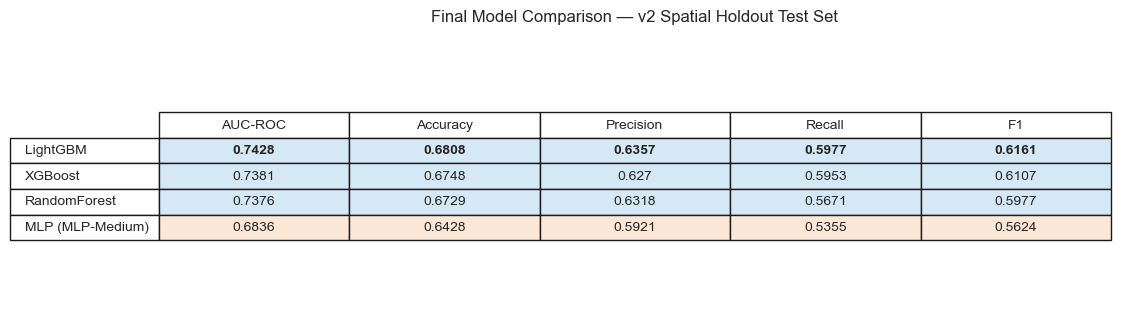

In [5]:
# Styled table figure
fig, ax = plt.subplots(figsize=(12, max(3, len(comp_df) * 0.6 + 1)))
ax.axis('off')

cat_colors = {'Ensemble (tuned)': '#d5e8f5', 'Ensemble (baseline)': '#e8f5e9',
              'Neural Network': '#fde8d8'}
row_colors = [[cat_colors.get(comp_df.loc[m, 'Category'], '#ffffff')] * len(metrics_cols)
              for m in comp_df.index]

tbl = ax.table(
    cellText  = comp_df[metrics_cols].values,
    rowLabels = comp_df.index.tolist(),
    colLabels = metrics_cols,
    cellColours = row_colors,
    loc='center', cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.3, 1.5)

# Bold best AUC row
best_idx = comp_df['AUC-ROC'].idxmax()
best_row  = comp_df.index.tolist().index(best_idx) + 1
for col in range(len(metrics_cols)):
    tbl[best_row, col].set_text_props(fontweight='bold')

plt.title('Final Model Comparison — v2 Spatial Holdout Test Set', fontsize=12, pad=15)
plt.tight_layout()
plt.savefig(OUTPUTS / 'v2_final_comparison_table.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. ROC Curves — All Models

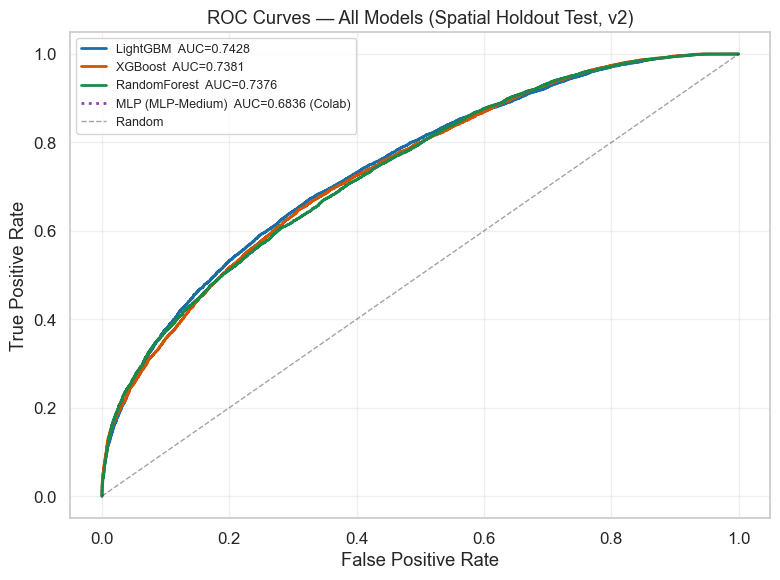

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))

palette = {
    'Ensemble (tuned)'   : ['#1a6ea8', '#d35400', '#1a8a4a'],
    'Ensemble (baseline)': ['#1a6ea8', '#d35400', '#1a8a4a'],
    'Neural Network'     : ['#8e44ad'],
}
color_iter = {cat: iter(cols) for cat, cols in palette.items()}

for name, m in sorted(results.items(), key=lambda x: -x[1]['AUC-ROC']):
    color = next(color_iter[m['category']])
    ls    = '-' if 'tuned' in m['category'] or m['category'] == 'Neural Network' else '--'
    if m['_prob'] is not None:
        fpr, tpr, _ = roc_curve(y_test, m['_prob'])
        ax.plot(fpr, tpr, color=color, lw=2, ls=ls,
                label=f'{name}  AUC={m["AUC-ROC"]:.4f}')
    else:
        # MLP — no probs available locally, just annotate AUC
        ax.plot([], [], color=color, lw=2, ls=':',
                label=f'{name}  AUC={m["AUC-ROC"]:.4f} (Colab)')

ax.plot([0,1],[0,1], 'k--', lw=1, alpha=0.4, label='Random')
ax.set(xlabel='False Positive Rate', ylabel='True Positive Rate',
       title='ROC Curves — All Models (Spatial Holdout Test, v2)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUTS / 'v2_roc_curves_final.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Confusion Matrices — Tuned Ensemble Models

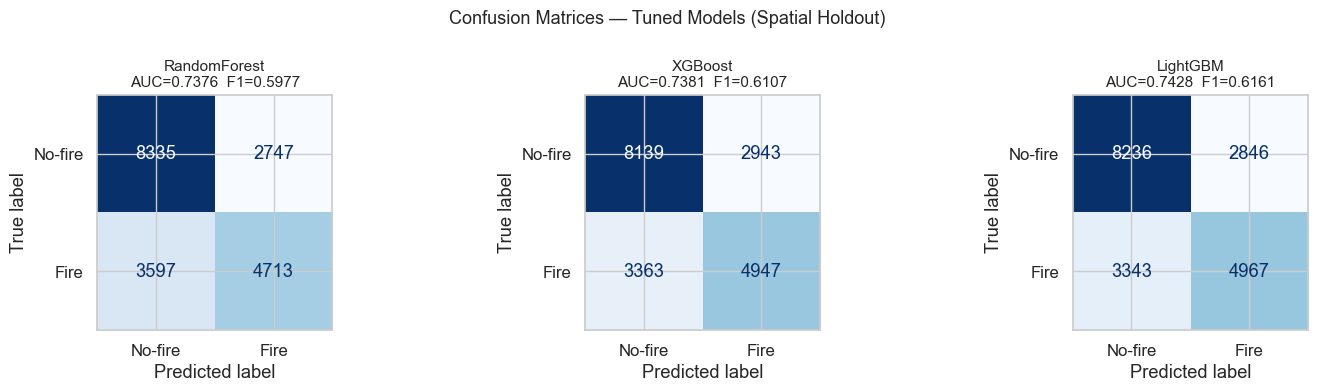

In [7]:
ensemble_models = [(n, m) for n, m in results.items()
                   if 'Ensemble' in m['category'] and m['_pred'] is not None]

if ensemble_models:
    fig, axes = plt.subplots(1, len(ensemble_models),
                             figsize=(5 * len(ensemble_models), 4))
    if len(ensemble_models) == 1:
        axes = [axes]
    for (name, m), ax in zip(ensemble_models, axes):
        cm   = confusion_matrix(y_test, m['_pred'])
        disp = ConfusionMatrixDisplay(cm, display_labels=['No-fire', 'Fire'])
        disp.plot(ax=ax, colorbar=False, cmap='Blues')
        ax.set_title(f'{name}\nAUC={m["AUC-ROC"]:.4f}  F1={m["F1"]:.4f}', fontsize=11)
    plt.suptitle('Confusion Matrices — Tuned Models (Spatial Holdout)', fontsize=13)
    plt.tight_layout()
    plt.savefig(OUTPUTS / 'v2_confusion_matrices_tuned.png', dpi=150, bbox_inches='tight')
    plt.show()

## 6. Tuning Gain vs Baseline

In [8]:
baseline_path = OUTPUTS / 'v2_baseline_metrics.json'
if baseline_path.exists() and tuned_path.exists():
    with open(baseline_path) as f:
        base_meta = {r['model']: r for r in json.load(f)}

    rows_gain = []
    for name in ['RandomForest', 'XGBoost', 'LightGBM']:
        if name in results and name in base_meta:
            rows_gain.append({
                'Model'          : name,
                'Baseline AUC'   : base_meta[name]['test_roc_auc'],
                'Tuned AUC'      : results[name]['AUC-ROC'],
                'AUC Gain'       : results[name]['AUC-ROC'] - base_meta[name]['test_roc_auc'],
                'Baseline F1'    : base_meta[name]['test_f1'],
                'Tuned F1'       : results[name]['F1'],
            })

    gain_df = pd.DataFrame(rows_gain).set_index('Model')
    print('=== TUNING GAIN ===')
    print(gain_df.round(4).to_string())
    gain_df

=== TUNING GAIN ===
              Baseline AUC  Tuned AUC  AUC Gain  Baseline F1  Tuned F1
Model                                                                 
RandomForest        0.7450     0.7376   -0.0074       0.6134    0.5977
XGBoost             0.7354     0.7381    0.0026       0.6139    0.6107
LightGBM            0.7355     0.7428    0.0073       0.6091    0.6161


## 7. Best Model Selection

In [9]:
# Best model = highest AUC-ROC among models with pkl available locally (needed for Phase 5)
local_models = {n: m for n, m in results.items() if m['_prob'] is not None}
best_name    = max(local_models, key=lambda n: local_models[n]['AUC-ROC'])
best_metrics = local_models[best_name]

print('=== BEST MODEL FOR PHASE 5 MAP GENERATION ===')
print(f'  Model   : {best_name}')
print(f'  AUC-ROC : {best_metrics["AUC-ROC"]:.4f}')
print(f'  F1      : {best_metrics["F1"]:.4f}')
print(f'  Category: {best_metrics["category"]}')

# Determine pkl path
pkl_key = best_name.lower().replace(' ', '')
best_pkl = MODELS_DIR / f'{pkl_key}_v2_best.pkl'
if not best_pkl.exists():
    best_pkl = MODELS_DIR / f'{pkl_key}_v2_baseline.pkl'
print(f'  pkl     : {best_pkl.name}')

# Save selection
selection = {
    'best_model_name': best_name,
    'best_model_pkl' : str(best_pkl),
    'test_auc'       : best_metrics['AUC-ROC'],
    'test_f1'        : best_metrics['F1'],
    'category'       : best_metrics['category'],
}
with open(OUTPUTS / 'best_model_v2.json', 'w') as f:
    json.dump(selection, f, indent=2)
print('  Saved: outputs/best_model_v2.json')

=== BEST MODEL FOR PHASE 5 MAP GENERATION ===
  Model   : LightGBM
  AUC-ROC : 0.7428
  F1      : 0.6161
  Category: Ensemble (tuned)
  pkl     : lightgbm_v2_best.pkl
  Saved: outputs/best_model_v2.json


## 8. Full Summary Figure

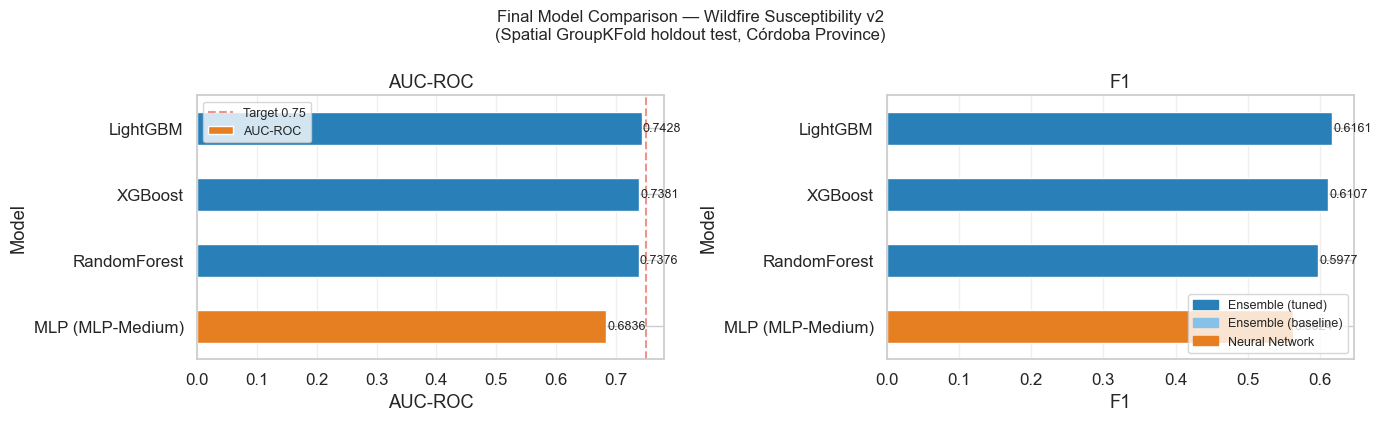

In [10]:
# Horizontal bar chart: AUC + F1 side by side
colors_map = {'Ensemble (tuned)': '#2980b9', 'Ensemble (baseline)': '#85c1e9',
              'Neural Network': '#e67e22'}

fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(comp_df) * 0.7 + 1.5)))
for ax, metric in [(axes[0], 'AUC-ROC'), (axes[1], 'F1')]:
    df_s   = comp_df.sort_values(metric, ascending=True)
    bar_colors = [colors_map.get(c, '#95a5a6') for c in df_s['Category']]
    df_s[metric].plot(kind='barh', ax=ax, color=bar_colors, edgecolor='white')
    ax.set(xlabel=metric, title=f'{metric}')
    ax.grid(axis='x', alpha=0.3)
    for i, v in enumerate(df_s[metric]):
        ax.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)
    if metric == 'AUC-ROC':
        ax.axvline(0.75, ls='--', color='#e74c3c', alpha=0.6, lw=1.5, label='Target 0.75')
        ax.legend(fontsize=9)

from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(color=c, label=k) for k, c in colors_map.items()],
               loc='lower right', fontsize=9)

plt.suptitle('Final Model Comparison — Wildfire Susceptibility v2\n'
             '(Spatial GroupKFold holdout test, Córdoba Province)', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUTS / 'v2_final_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Verification

In [11]:
print('=== EVALUATION V2 VERIFICATION ===')

assert len(results) > 0, 'No models evaluated'
print(f'  [OK] {len(results)} models evaluated')

best_auc = comp_df['AUC-ROC'].max()
target_met = best_auc >= 0.75
print(f'  [{"OK" if target_met else "WARN"}] Best AUC={best_auc:.4f} '
      f'({"≥" if target_met else "<"} 0.75 target)')

for fname in ['v2_final_comparison_table.png', 'v2_roc_curves_final.png',
               'v2_final_model_comparison.png', 'best_model_v2.json']:
    exists = (OUTPUTS / fname).exists()
    print(f'  [{"OK" if exists else "MISSING"}] {fname}')

# CV vs test gap for best local model
if (OUTPUTS / 'v2_tuned_metrics.json').exists():
    with open(OUTPUTS / 'v2_tuned_metrics.json') as f:
        tuned_list = json.load(f)
    for r in tuned_list:
        gap = abs(r['cv_auc_best'] - r['test_roc_auc'])
        flag = '[OVERFIT?]' if gap > 0.08 else '[OK]'
        print(f'  {flag} {r["model"]:15s} CV-test gap={gap:.4f}')

print(f'\nBest model for Phase 5: {best_name}')
print('Next: Phase 5 — predict_grid.py (susceptibility map generation)')

=== EVALUATION V2 VERIFICATION ===
  [OK] 4 models evaluated
  [WARN] Best AUC=0.7428 (< 0.75 target)
  [OK] v2_final_comparison_table.png
  [OK] v2_roc_curves_final.png
  [OK] v2_final_model_comparison.png
  [OK] best_model_v2.json
  [OK] RandomForest    CV-test gap=0.0463
  [OK] XGBoost         CV-test gap=0.0395
  [OK] LightGBM        CV-test gap=0.0365

Best model for Phase 5: LightGBM
Next: Phase 5 — predict_grid.py (susceptibility map generation)
